## Assignment 04 - Deadline: Mar 29, 2026, Sun 11pm

#### DSAI 541 Spring 2026

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.bogazici.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time and no late homeworks will be accepted.


To make a pdf, this may work if you're using Jupyter notebook on browser: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu. (You can use Google Colab, but at the end you should download the ipynb notebook to submit it on Moodle.)

In [4]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# Set the display option to show all rows scrolling with a slider
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

np.random.seed(42)
torch.manual_seed(42)

# Problem 1: ANN hyperparameter optimization with Breast Cancer Dataset (100 pts)

(You must use PyTorch in this problem. Answers implemented in TensorFlow will not be accepted.)

In this problem, you will use Breast Cancer Wisconsin dataset to train ANN classifier. The two classes in the dataset are malignant tumor (M) and benign tumor (B).

a) Load the Breast Cancer Wisconsin dataset. Split the dataset into training, validation and test sets. Then standardize the features using StandardScaler() while avoiding data leakage.

b) You will train an ANN binary classifier with two hidden layers. Choose three values for each of these three hyperparameters: Learning rate, batch size and number of neurons, assuming that both hidden layers have the same number of neurons. You will train $3\times3\times3=27$ models using early stopping.

c) Train the models and calculate accuracy, recall, precision and F1 score on the validation set for each model.

d) Which classification metric should you use assuming false negatives are more costly than false positives? What are the hyperparameters of the best model, which maximizes that metric?

e) Perform the final training of your best model and show training and validation curves. Show the confusion matrix with labels "actual" and "predicted" as we did in class.

f) Calculate the evaluation metric you choose in d) on the test set.

#### Part a)

In [5]:
# Load the dataset
df = pd.read_csv("Breast_Cancer_Wisconsin.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')

In [7]:
# Drop the 'id' column, any unnamed columns, and encode the target variable
df = df.drop(columns=["id"])
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Encode diagnosis: M=1 (malignant), B=0 (benign)
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # B=0, M=1
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Class distribution:\n", df["diagnosis"].value_counts())
print("Dataset shape after cleaning:", df.shape)

# Separate features and target
X = df.drop(columns=["diagnosis"]).values
y = df["diagnosis"].values


Class mapping: {'B': np.int64(0), 'M': np.int64(1)}
Class distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64
Dataset shape after cleaning: (569, 31)


In [8]:
# Split into train (60%), validation (20%), test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])

# Standardize features using StandardScaler (fit only on training data to avoid data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("\nTensor shapes:")
print(f"X_train: {X_train_t.shape}, y_train: {y_train_t.shape}")
print(f"X_val: {X_val_t.shape}, y_val: {y_val_t.shape}")
print(f"X_test: {X_test_t.shape}, y_test: {y_test_t.shape}")


Train set size: 341
Validation set size: 114
Test set size: 114

Tensor shapes:
X_train: torch.Size([341, 30]), y_train: torch.Size([341, 1])
X_val: torch.Size([114, 30]), y_val: torch.Size([114, 1])
X_test: torch.Size([114, 30]), y_test: torch.Size([114, 1])


#### Part b)

In [9]:
# Define the ANN model with two hidden layers
class ANNClassifier(nn.Module):
    def __init__(self, input_dim, n_neurons):
        super(ANNClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, n_neurons),
            nn.ReLU(),
            nn.Linear(n_neurons, n_neurons),
            nn.ReLU(),
            nn.Linear(n_neurons, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

# Define three values for each hyperparameter
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [16, 32, 64]
neuron_counts = [16, 32, 64]

print("Hyperparameter grid:")
print(f"Learning rates: {learning_rates}")
print(f"Batch sizes: {batch_sizes}")
print(f"Neuron counts: {neuron_counts}")
print(f"Total combinations: {len(learning_rates) * len(batch_sizes) * len(neuron_counts)}")


Hyperparameter grid:
Learning rates: [0.001, 0.01, 0.1]
Batch sizes: [16, 32, 64]
Neuron counts: [16, 32, 64]
Total combinations: 27


#### Part c)

In [10]:
# Training function with early stopping
def train_model(X_train_t, y_train_t, X_val_t, y_val_t, lr, batch_size, n_neurons, 
                max_epochs=500, patience=20):
    input_dim = X_train_t.shape[1]
    model = ANNClassifier(input_dim, n_neurons)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0
    train_losses = []
    val_losses = []
    
    for epoch in range(max_epochs):
        # Training
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch_X.size(0)
        
        train_loss = epoch_loss / len(train_dataset)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t).item()
            val_losses.append(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= patience:
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

# Train all 27 models and evaluate on validation set
results = []
input_dim = X_train_t.shape[1]

print("Training 27 models...")
print("-" * 90)

for lr in learning_rates:
    for bs in batch_sizes:
        for nn_count in neuron_counts:
            torch.manual_seed(42)
            np.random.seed(42)
            
            model, train_losses, val_losses = train_model(
                X_train_t, y_train_t, X_val_t, y_val_t,
                lr=lr, batch_size=bs, n_neurons=nn_count
            )
            
            # Evaluate on validation set
            model.eval()
            with torch.no_grad():
                val_preds_prob = model(X_val_t)
                val_preds = (val_preds_prob >= 0.5).float().numpy()
                y_val_np = y_val_t.numpy()
            
            acc = accuracy_score(y_val_np, val_preds)
            rec = recall_score(y_val_np, val_preds)
            prec = precision_score(y_val_np, val_preds)
            f1 = f1_score(y_val_np, val_preds)
            
            results.append({
                'lr': lr, 'batch_size': bs, 'n_neurons': nn_count,
                'accuracy': acc, 'recall': rec, 'precision': prec, 'f1': f1,
                'model': model, 'train_losses': train_losses, 'val_losses': val_losses,
                'epochs': len(train_losses)
            })
            
            print(f"LR={lr:<6} BS={bs:<4} Neurons={nn_count:<4} | "
                  f"Acc={acc:.4f}  Rec={rec:.4f}  Prec={prec:.4f}  F1={f1:.4f}  Epochs={len(train_losses)}")

print("-" * 90)
print("Training complete!")


Training 27 models...
------------------------------------------------------------------------------------------
LR=0.001  BS=16   Neurons=16   | Acc=0.9825  Rec=0.9535  Prec=1.0000  F1=0.9762  Epochs=52
LR=0.001  BS=16   Neurons=32   | Acc=0.9825  Rec=0.9535  Prec=1.0000  F1=0.9762  Epochs=35
LR=0.001  BS=16   Neurons=64   | Acc=0.9737  Rec=0.9302  Prec=1.0000  F1=0.9639  Epochs=31
LR=0.001  BS=32   Neurons=16   | Acc=0.9825  Rec=0.9535  Prec=1.0000  F1=0.9762  Epochs=69
LR=0.001  BS=32   Neurons=32   | Acc=0.9825  Rec=0.9535  Prec=1.0000  F1=0.9762  Epochs=49
LR=0.001  BS=32   Neurons=64   | Acc=0.9737  Rec=0.9302  Prec=1.0000  F1=0.9639  Epochs=38
LR=0.001  BS=64   Neurons=16   | Acc=0.9825  Rec=0.9535  Prec=1.0000  F1=0.9762  Epochs=117
LR=0.001  BS=64   Neurons=32   | Acc=0.9825  Rec=0.9535  Prec=1.0000  F1=0.9762  Epochs=74
LR=0.001  BS=64   Neurons=64   | Acc=0.9912  Rec=0.9767  Prec=1.0000  F1=0.9882  Epochs=38
LR=0.01   BS=16   Neurons=16   | Acc=0.9825  Rec=0.9535  Prec=1.000

In [11]:
# Display results as a DataFrame
results_df = pd.DataFrame([{
    'Learning Rate': r['lr'], 'Batch Size': r['batch_size'], 'Neurons': r['n_neurons'],
    'Accuracy': round(r['accuracy'], 4), 'Recall': round(r['recall'], 4),
    'Precision': round(r['precision'], 4), 'F1 Score': round(r['f1'], 4),
    'Epochs': r['epochs']
} for r in results])

results_df

,Learning Rate,Batch Size,Neurons,Accuracy,Recall,Precision,F1 Score,Epochs
0,0.001,16,16,0.9825,0.9535,1.0000,0.9762,52
1,0.001,16,32,0.9825,0.9535,1.0000,0.9762,35
2,0.001,16,64,0.9737,0.9302,1.0000,0.9639,31
3,0.001,32,16,0.9825,0.9535,1.0000,0.9762,69
4,0.001,32,32,0.9825,0.9535,1.0000,0.9762,49
5,0.001,32,64,0.9737,0.9302,1.0000,0.9639,38
6,0.001,64,16,0.9825,0.9535,1.0000,0.9762,117
7,0.001,64,32,0.9825,0.9535,1.0000,0.9762,74
8,0.001,64,64,0.9912,0.9767,1.0000,0.9882,38
9,0.010,16,16,0.9825,0.9535,1.0000,0.9762,29


#### Part d)

In [12]:
print("The best metric to use when false negatives are more costly is: RECALL")
print("Recall measures the proportion of actual positives that are correctly identified.")
print("Maximizing recall minimizes the chance of missing a malignant tumor.\n")

# Find the best model based on recall
best_idx = max(range(len(results)), key=lambda i: results[i]['recall'])
best = results[best_idx]

print(f"Best model hyperparameters (maximizing recall):")
print(f"  Learning Rate: {best['lr']}")
print(f"  Batch Size:    {best['batch_size']}")
print(f"  Neurons:       {best['n_neurons']}")
print(f"\nValidation metrics of the best model:")
print(f"  Accuracy:  {best['accuracy']:.4f}")
print(f"  Recall:    {best['recall']:.4f}")
print(f"  Precision: {best['precision']:.4f}")
print(f"  F1 Score:  {best['f1']:.4f}")

The best metric to use when false negatives are more costly is: RECALL
Recall measures the proportion of actual positives that are correctly identified.
Maximizing recall minimizes the chance of missing a malignant tumor.

Best model hyperparameters (maximizing recall):
  Learning Rate: 0.1
  Batch Size:    32
  Neurons:       64

Validation metrics of the best model:
  Accuracy:  1.0000
  Recall:    1.0000
  Precision: 1.0000
  F1 Score:  1.0000


#### Part e)

In [13]:
# Final training of the best model with the best hyperparameters
best_lr = best['lr']
best_bs = best['batch_size']
best_nn = best['n_neurons']

torch.manual_seed(42)
np.random.seed(42)

final_model, final_train_losses, final_val_losses = train_model(
    X_train_t, y_train_t, X_val_t, y_val_t,
    lr=best_lr, batch_size=best_bs, n_neurons=best_nn,
    max_epochs=500, patience=20
)

print(f"Final model trained for {len(final_train_losses)} epochs")
print(f"Hyperparameters: LR={best_lr}, Batch Size={best_bs}, Neurons={best_nn}")

Final model trained for 39 epochs
Hyperparameters: LR=0.1, Batch Size=32, Neurons=64


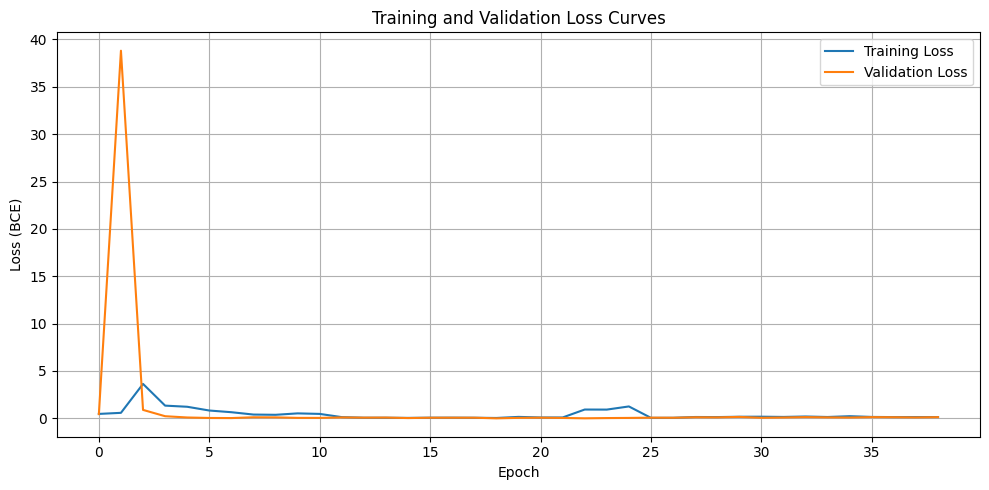

In [14]:
# Plot training and validation loss curves
plt.figure(figsize=(10, 5))
plt.plot(final_train_losses, label='Training Loss')
plt.plot(final_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

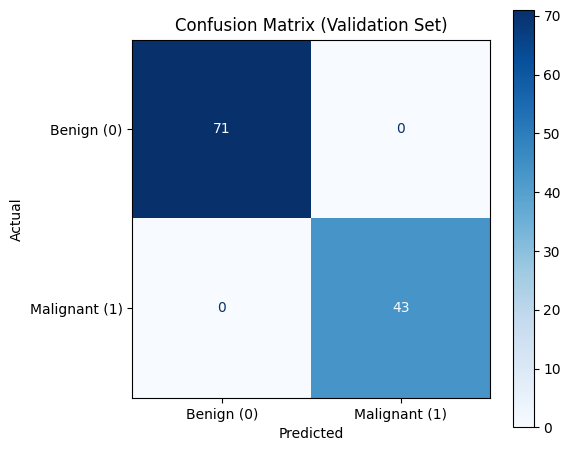

In [15]:
# Confusion Matrix on validation set
final_model.eval()
with torch.no_grad():
    val_preds_prob = final_model(X_val_t)
    val_preds = (val_preds_prob >= 0.5).float().numpy()
    y_val_np = y_val_t.numpy()

cm = confusion_matrix(y_val_np, val_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()


#### Part f)

Test Set Evaluation:
  Accuracy:  0.9825
  Recall:    0.9524
  Precision: 1.0000
  F1 Score:  0.9756

The chosen metric (Recall) on the test set: 0.9524


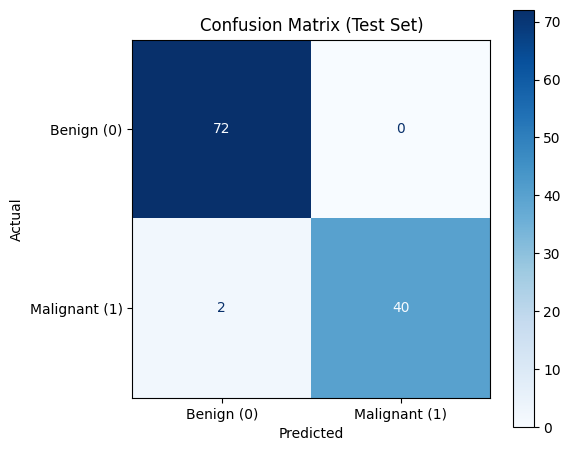

In [16]:
# Evaluate the best model on the test set using recall
final_model.eval()
with torch.no_grad():
    test_preds_prob = final_model(X_test_t)
    test_preds = (test_preds_prob >= 0.5).float().numpy()
    y_test_np = y_test_t.numpy()

test_acc = accuracy_score(y_test_np, test_preds)
test_rec = recall_score(y_test_np, test_preds)
test_prec = precision_score(y_test_np, test_preds)
test_f1 = f1_score(y_test_np, test_preds)

print("Test Set Evaluation:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Recall:    {test_rec:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
print(f"\nThe chosen metric (Recall) on the test set: {test_rec:.4f}")

# Also show confusion matrix on test set
cm_test = confusion_matrix(y_test_np, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()
